# Open SPE9 subsurface data with XTGeo, XTGeoViz, and NeqSim

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/xtgeo_spe9_subsurface_to_neqsim.ipynb)

This detailed tutorial turns a checksum-controlled, openly licensed SPE9 corner-point model into a
unit-explicit subsurface-to-facilities screening workflow.

You will learn to:

1. download and verify public ECLIPSE-format data from an immutable Git commit;
2. read grid geometry, static properties, pressure, and saturations with **XTGeo**;
3. render XTGeo surfaces and candidate locations with **XTGeoViz**;
4. audit field-unit pore volume and estimate hydrocarbon pore volume and oil in place;
5. rank spaced candidate well columns with a transparent quality proxy;
6. propagate stated early-phase uncertainty without relabelling it as measured data; and
7. translate three rate cases into a composable **NeqSim** separation and compression model.

The notebook is educational screening material. It is not a history match, reserves statement,
well-placement recommendation, or certified process design.

## 1. Model ownership and the handoff

| Step | Governing source or tool | What is carried forward |
|---|---|---|
| Grid and properties | Public SPE9 files through XTGeo | geometry, porosity, permeability, pore volume |
| Initial state | Public `INITSOL.INC` through XTGeo | pressure, water/gas saturation, solution GOR |
| Maps and candidates | XTGeo + XTGeoViz | traceable column aggregates and locations |
| PVT bridge | SPE9 black-oil table + an explicitly illustrative NeqSim assay | rate and phase-load scenarios |
| Facility screen | NeqSim `Stream`, valves, cooler, separators, compressors | mass closure, power, cooling, utilization |

The data contract is deliberately one-way:

$$\mathrm{EGRID}+\mathrm{INIT}+\mathrm{INITSOL}\rightarrow\mathrm{XTGeo\ QC}\rightarrow\mathrm{volumetrics}\rightarrow\mathrm{rate\ cases}\rightarrow\mathrm{NeqSim\ facilities}$$

NeqSim does not reinterpret the static grid. XTGeo does not replace PVT experiments or a reservoir
simulator. Each result keeps its owner, unit, and limitation.

In [1]:
%pip install -q neqsim xtgeo xtgeoviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import hashlib
from importlib.metadata import version
import json
import math
from pathlib import Path
import platform
import re
import subprocess
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xtgeo
from xtgeoviz.plot import Map

from neqsim import jneqsim
from neqsim.thermo import TPflash
from neqsim.process.processTools import (
    clearProcess,
    compressor,
    cooler,
    mixer,
    runProcess,
    separator,
    separator3phase,
    stream,
    valve,
)


plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

SECONDS_PER_DAY = 86_400.0
PSI_TO_BAR = 0.0689475729
RESERVOIR_BARREL_TO_M3 = 0.158987294928
MCSF_PER_STB_TO_SM3_PER_SM3 = 178.107606679
FT3_PER_RESERVOIR_BARREL = 5.614583333333333
STANDARD_TEMPERATURE_C = 15.0
STANDARD_PRESSURE_BARA = 1.01325
RANDOM_SEED = 20260823

java_version = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

environment_table = pd.DataFrame(
    {
        "dependency": ["Python", "Java", "XTGeo", "XTGeoViz", "NeqSim"],
        "resolved version": [
            platform.python_version(),
            java_version,
            version("xtgeo"),
            version("xtgeoviz"),
            version("neqsim"),
        ],
    }
)
display(environment_table)

,dependency,resolved version
0,Python,3.12.13
1,Java,"openjdk version ""17.0.19"" 2026-04-21"
2,XTGeo,4.25.1
3,XTGeoViz,0.3.2
4,NeqSim,3.18.0


## 2. Open data, licence, and immutable provenance

The files come from [`equinor/xtgeo-testdata`](https://github.com/equinor/xtgeo-testdata) at commit
`cad17f24e22c19c6cefe6f647185395cc0a11add`. The repository releases its grids, surfaces, cubes,
and wells under **LGPL-3.0**. SPE9 is a public comparative black-oil benchmark rather than an asset
model. Its synthetic geometry and properties must not be described as field observations.

The four files used here are:

- `BENCH_SPE9.EGRID`: 3-D corner-point geometry;
- `BENCH_SPE9.INIT`: static properties such as `PORO`, `PERMX`, `PORV`, and dimensions;
- `INITSOL.INC`: initial `PRESSURE`, `SWAT`, `SGAS`, and `RS`; and
- `BENCH_SPE9.DATA`: `FIELD` units and black-oil PVT tables.

Every download is tied to the commit and checked against a stored SHA-256 digest before parsing.

In [3]:
DATA_COMMIT = "cad17f24e22c19c6cefe6f647185395cc0a11add"
DATA_DIRECTORY = Path("/tmp/neqsim_xtgeo_spe9")
DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)

DATA_FILES = {
    "BENCH_SPE9.DATA": "8355bcf81ad2f9e8b0abcf0c6266f4e9ddc73d7cce672e9cbd5c374e6e7b9e95",
    "BENCH_SPE9.EGRID": "dbb6e66ee9baf8f209d08f44aae9490b195d5c135ebe5b4ebfa4d1210e8bbfcc",
    "BENCH_SPE9.INIT": "084ed7bc0758b679947dc9501f6ff7b9031cd2328dce164af2a79cb3cbd05ddf",
    "INITSOL.INC": "d4a4f9387c886e28cf2080ce7b4b100cc3081cfda44cea5a17f9422ef171c304",
}
RAW_ROOT = (
    "https://raw.githubusercontent.com/equinor/xtgeo-testdata/"
    f"{DATA_COMMIT}/3dgrids/bench_spe9"
)


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


download_rows = []
for file_name, expected_digest in DATA_FILES.items():
    destination = DATA_DIRECTORY / file_name
    if not destination.exists() or sha256(destination) != expected_digest:
        urlretrieve(f"{RAW_ROOT}/{file_name}", destination)
    actual_digest = sha256(destination)
    if actual_digest != expected_digest:
        raise ValueError(f"Checksum mismatch for {file_name}")
    download_rows.append(
        {
            "file": file_name,
            "bytes": destination.stat().st_size,
            "sha256": actual_digest,
            "verified": True,
        }
    )

download_table = pd.DataFrame(download_rows)
display(download_table)
print(f"Verified {len(download_table)} public files at commit {DATA_COMMIT}.")

Verified 4 public files at commit cad17f24e22c19c6cefe6f647185395cc0a11add.


,file,bytes,sha256,verified
0,BENCH_SPE9.DATA,154094,8355bcf81ad2f9e8b0abcf0c6266f4e9ddc73d7cce672e...,True
1,BENCH_SPE9.EGRID,341288,dbb6e66ee9baf8f209d08f44aae9490b195d5c135ebe5b...,True
2,BENCH_SPE9.INIT,639520,084ed7bc0758b679947dc9501f6ff7b9031cd2328dce16...,True
3,INITSOL.INC,486046,d4a4f9387c886e28cf2080ce7b4b100cc3081cfda44cea...,True


## 3. Read geometry, static properties, and initial state with XTGeo

`grid_from_file` reads the EGRID geometry. `gridproperties_from_file` loads a selected, auditable
set from INIT rather than silently importing every vector. The GRDECL reader then links initial
pressure and saturations to the same grid.

The benchmark has $24\times25\times15=9000$ active cells. All array operations below retain the
native XTGeo ordering $(I,J,K)$.

In [4]:
grid_path = DATA_DIRECTORY / "BENCH_SPE9.EGRID"
init_path = DATA_DIRECTORY / "BENCH_SPE9.INIT"
initial_solution_path = DATA_DIRECTORY / "INITSOL.INC"
deck_path = DATA_DIRECTORY / "BENCH_SPE9.DATA"

grid = xtgeo.grid_from_file(grid_path)
static_property_names = [
    "PORV",
    "PORO",
    "PERMX",
    "NTG",
    "DX",
    "DY",
    "DZ",
    "DEPTH",
    "FIPNUM",
]
static_properties = xtgeo.gridproperties_from_file(
    init_path,
    names=static_property_names,
    grid=grid,
)
property_by_name = {
    grid_property.name: grid_property
    for grid_property in static_properties.props
}

for property_name in ["PRESSURE", "SWAT", "SGAS", "RS"]:
    property_by_name[property_name] = xtgeo.gridproperty_from_file(
        initial_solution_path,
        fformat="grdecl",
        name=property_name,
        grid=grid,
    )

grid_summary = pd.DataFrame(
    {
        "quantity": [
            "I columns",
            "J rows",
            "K layers",
            "total cells",
            "active cells",
            "loaded properties",
        ],
        "value": [
            grid.ncol,
            grid.nrow,
            grid.nlay,
            grid.ntotal,
            grid.nactive,
            len(property_by_name),
        ],
        "unit": ["count", "count", "count", "count", "count", "count"],
    }
)
display(grid_summary)

property_summary_rows = []
for property_name, grid_property in property_by_name.items():
    values = grid_property.values
    property_summary_rows.append(
        {
            "property": property_name,
            "minimum": float(np.ma.min(values)),
            "mean": float(np.ma.mean(values)),
            "maximum": float(np.ma.max(values)),
            "discrete": bool(grid_property.isdiscrete),
        }
    )

property_summary = pd.DataFrame(property_summary_rows)
display(property_summary.round(5))

,quantity,value,unit
0,I columns,24,count
1,J rows,25,count
2,K layers,15,count
3,total cells,9000,count
4,active cells,9000,count
5,loaded properties,13,count


,property,minimum,mean,maximum,discrete
0,PORV,10258.99805,50323.59128,251666.04688,False
1,PORO,0.08000,0.12620,0.17000,False
2,PERMX,0.00307,108.08240,10053.79688,False
3,NTG,1.00000,1.00000,1.00000,False
4,DX,300.00000,300.00000,300.00000,False
5,DY,300.00000,300.00000,300.00000,False
6,DZ,8.00000,23.93333,100.00000,False
7,DEPTH,9010.00000,9736.69463,10525.66016,False
8,FIPNUM,1.00000,1.00000,1.00000,True
9,PRESSURE,3590.25464,3876.09982,4205.05713,False


## 4. Unit audit and pore-volume identity

The deck declares `FIELD` units. INIT therefore reports $D_X,D_Y,D_Z$ in ft, permeability in mD,
pressure in psia, solution GOR $R_s$ in Mscf/STB, and pore volume `PORV` in reservoir barrels (RB).
The EGRID depth coordinates are exposed by XTGeo in metres, while horizontal model coordinates keep
the benchmark grid coordinate scale. No projected CRS is supplied, so the horizontal axes must not
be plotted as UTM.

For every active cell, the black-oil pore-volume identity is

$$V_{p,\mathrm{RB}}=\frac{\phi N_TD_XD_YD_Z}{5.614583333}$$

and initial hydrocarbon pore volume is

$$V_{HC,\mathrm{RB}}=V_{p,\mathrm{RB}}(1-S_w-S_g)$$

This is a strong analytical check because it independently reconstructs the stored `PORV` vector
from porosity, net-to-gross, and geometry.

In [5]:
values = {
    property_name: grid_property.values
    for property_name, grid_property in property_by_name.items()
}

calculated_pore_volume_rb = (
    values["PORO"]
    * values["NTG"]
    * values["DX"]
    * values["DY"]
    * values["DZ"]
    / FT3_PER_RESERVOIR_BARREL
)
pore_volume_relative_residual = (
    calculated_pore_volume_rb - values["PORV"]
) / values["PORV"]
maximum_pore_volume_relative_residual = float(
    np.ma.max(np.ma.abs(pore_volume_relative_residual))
)

hydrocarbon_saturation = 1.0 - values["SWAT"] - values["SGAS"]
hydrocarbon_pore_volume_rb = values["PORV"] * hydrocarbon_saturation
hydrocarbon_pore_volume_m3 = (
    hydrocarbon_pore_volume_rb * RESERVOIR_BARREL_TO_M3
)

pore_volume_m3 = float(
    np.ma.sum(values["PORV"]) * RESERVOIR_BARREL_TO_M3
)
hydrocarbon_pore_volume_total_m3 = float(
    np.ma.sum(hydrocarbon_pore_volume_m3)
)
weighted_initial_pressure_bara = float(
    np.ma.average(values["PRESSURE"], weights=values["PORV"])
    * PSI_TO_BAR
)
weighted_initial_water_saturation = float(
    np.ma.average(values["SWAT"], weights=values["PORV"])
)
weighted_solution_gor_mscf_stb = float(
    np.ma.average(values["RS"], weights=values["PORV"])
)

unit_audit_table = pd.DataFrame(
    {
        "quantity": [
            "total pore volume",
            "initial hydrocarbon pore volume",
            "pore-volume reconstruction residual",
            "pore-volume-weighted pressure",
            "pore-volume-weighted water saturation",
            "pore-volume-weighted solution GOR",
        ],
        "value": [
            pore_volume_m3 / 1.0e6,
            hydrocarbon_pore_volume_total_m3 / 1.0e6,
            maximum_pore_volume_relative_residual,
            weighted_initial_pressure_bara,
            weighted_initial_water_saturation,
            weighted_solution_gor_mscf_stb,
        ],
        "unit": [
            "million reservoir m3",
            "million reservoir m3",
            "fraction",
            "bara",
            "fraction",
            "Mscf/STB",
        ],
    }
)
display(unit_audit_table.round(6))

,quantity,value,unit
0,total pore volume,72.007305,million reservoir m3
1,initial hydrocarbon pore volume,37.787417,million reservoir m3
2,pore-volume reconstruction residual,0.000000,fraction
3,pore-volume-weighted pressure,268.971411,bara
4,pore-volume-weighted water saturation,0.475228,fraction
5,pore-volume-weighted solution GOR,1.389994,Mscf/STB


## 5. Grid geometry as an XTGeo surface and XTGeoViz map

`surface_from_grid3d` samples the top of the corner-point grid onto its native map geometry. The
XTGeoViz `Map` class is used directly so contour density, colour map, axes, and annotations stay
under notebook control. The saved notebook output is a static Matplotlib rendering, so no separate
interactive-viewer fallback is required.

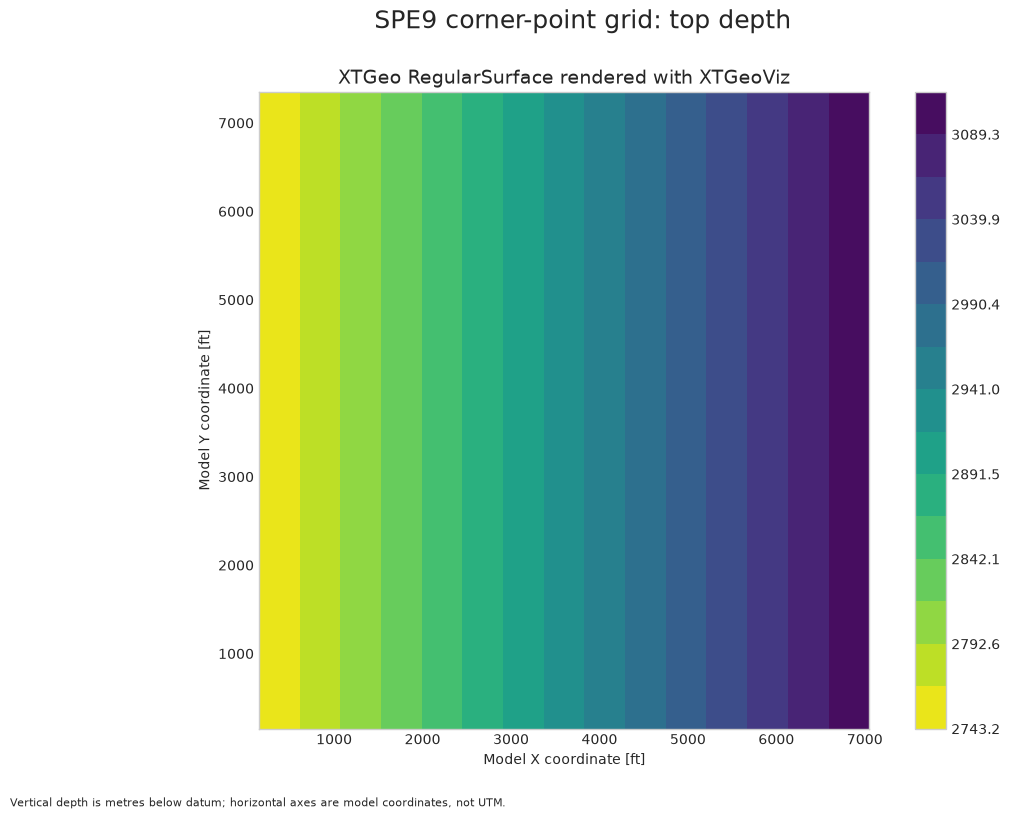

True

In [6]:
top_depth_surface = xtgeo.surface_from_grid3d(
    grid,
    template="native",
    where="top",
    property="depth",
)

top_depth_map = Map()
top_depth_map.contourlevels = 16
top_depth_map.canvas(
    title="SPE9 corner-point grid: top depth",
    subtitle="XTGeo RegularSurface rendered with XTGeoViz",
    infotext=(
        "Vertical depth is metres below datum; horizontal axes are model coordinates, not UTM."
    ),
)
top_depth_map.plot_surface(
    top_depth_surface,
    colormap=plt.get_cmap("viridis_r"),
)
top_depth_map._ax.set_xlabel("Model X coordinate [ft]")
top_depth_map._ax.set_ylabel("Model Y coordinate [ft]")
top_depth_map.show()

## 6. Petrophysical quality control

The benchmark permeability spans several orders of magnitude, so a logarithmic axis is essential.
The plots answer two different questions:

- distributions show whether porosity, permeability, and water saturation occupy physical ranges;
- the cross-plot shows whether permeability variability is explained by porosity alone.

The plots are descriptive. They do not establish a petrophysical transform or uncertainty model.

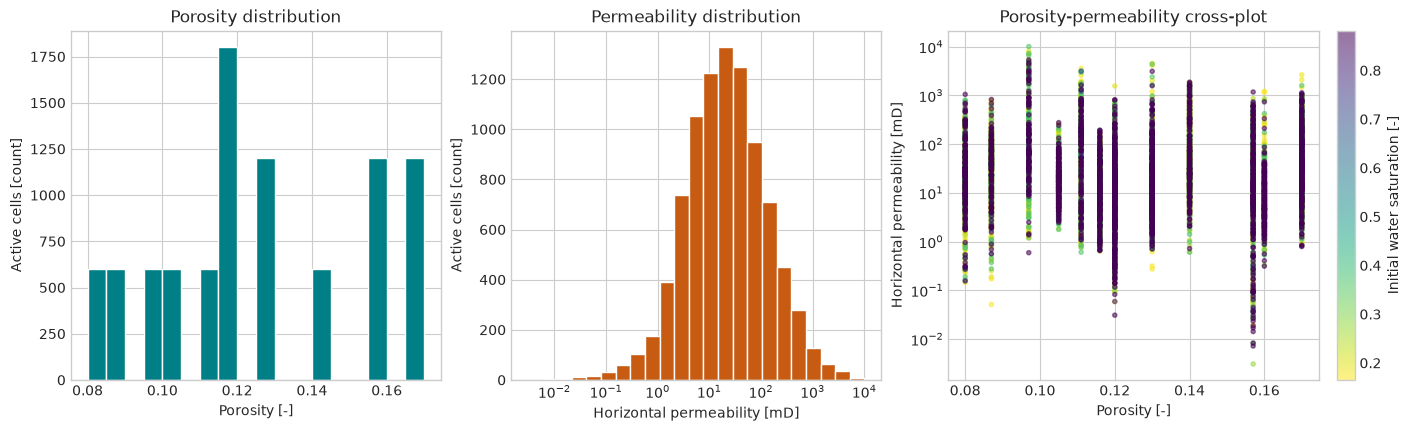

In [7]:
active_porosity = np.ma.compressed(values["PORO"])
active_permeability_md = np.ma.compressed(values["PERMX"])
active_water_saturation = np.ma.compressed(values["SWAT"])

figure, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.2),
    constrained_layout=True,
)
axes[0].hist(active_porosity, bins=18, color="#007F87", edgecolor="white")
axes[0].set_xlabel("Porosity [-]")
axes[0].set_ylabel("Active cells [count]")
axes[0].set_title("Porosity distribution")

axes[1].hist(
    active_permeability_md,
    bins=np.logspace(
        np.log10(active_permeability_md.min()),
        np.log10(active_permeability_md.max()),
        24,
    ),
    color="#C75B12",
    edgecolor="white",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("Horizontal permeability [mD]")
axes[1].set_ylabel("Active cells [count]")
axes[1].set_title("Permeability distribution")

scatter = axes[2].scatter(
    active_porosity,
    active_permeability_md,
    c=active_water_saturation,
    cmap="viridis_r",
    s=9,
    alpha=0.55,
)
axes[2].set_yscale("log")
axes[2].set_xlabel("Porosity [-]")
axes[2].set_ylabel("Horizontal permeability [mD]")
axes[2].set_title("Porosity-permeability cross-plot")
figure.colorbar(scatter, ax=axes[2], label="Initial water saturation [-]")
plt.show()

## 7. Column aggregation and a transparent well-location proxy

Hydrocarbon pore volume is summed through all layers. A simple screening score combines connected
volume with a permeability-thickness proxy:

$$S_{ij}=V_{HC,ij}\ln\left(1+\sum_k k_{x,ijk}D_{Z,ijk}S_{HC,ijk}\right)$$

The score is **not** an economic objective and does not replace streamline analysis, faults,
geomechanics, well trajectories, or a dynamic simulator. A greedy spacing rule keeps five selected
columns at least five Manhattan grid steps apart, making the ranking reproducible and avoiding a
cluster of adjacent top cells.

In [8]:
column_hcpv_m3 = np.ma.sum(hydrocarbon_pore_volume_m3, axis=2)
column_kh_proxy_md_ft = np.ma.sum(
    values["PERMX"] * values["DZ"] * hydrocarbon_saturation,
    axis=2,
)
screening_score = column_hcpv_m3 * np.log1p(column_kh_proxy_md_ft)

rank_order = np.argsort(
    np.ma.filled(screening_score, -np.inf).ravel()
)[::-1]
selected_columns = []
for flat_index in rank_order:
    i_index, j_index = np.unravel_index(
        int(flat_index),
        screening_score.shape,
    )
    is_spaced = all(
        abs(i_index - previous_i) + abs(j_index - previous_j) >= 5
        for previous_i, previous_j in selected_columns
    )
    if is_spaced:
        selected_columns.append((i_index, j_index))
    if len(selected_columns) == 5:
        break

x_coordinates, y_coordinates, _ = grid.get_xyz()
candidate_rows = []
for rank, (i_index, j_index) in enumerate(selected_columns, start=1):
    candidate_rows.append(
        {
            "rank": rank,
            "I": i_index + 1,
            "J": j_index + 1,
            "model X [ft]": float(x_coordinates.values[i_index, j_index, 0]),
            "model Y [ft]": float(y_coordinates.values[i_index, j_index, 0]),
            "column HCPV [million rm3]": float(
                column_hcpv_m3[i_index, j_index] / 1.0e6
            ),
            "kh proxy [mD ft]": float(
                column_kh_proxy_md_ft[i_index, j_index]
            ),
            "screening score": float(screening_score[i_index, j_index]),
        }
    )

candidate_table = pd.DataFrame(candidate_rows)
display(candidate_table.round(3))

,rank,I,J,model X [ft],model Y [ft],column HCPV [million rm3],kh proxy [mD ft],screening score
0,1,3,9,750.0,2550.0,0.099,107760.642,1141948.200
1,2,1,15,150.0,4350.0,0.099,59869.240,1093608.219
2,3,3,25,750.0,7350.0,0.099,65925.647,1093523.530
3,4,6,17,1650.0,4950.0,0.096,90413.548,1090613.629
4,5,2,20,450.0,5850.0,0.099,57859.810,1086340.731


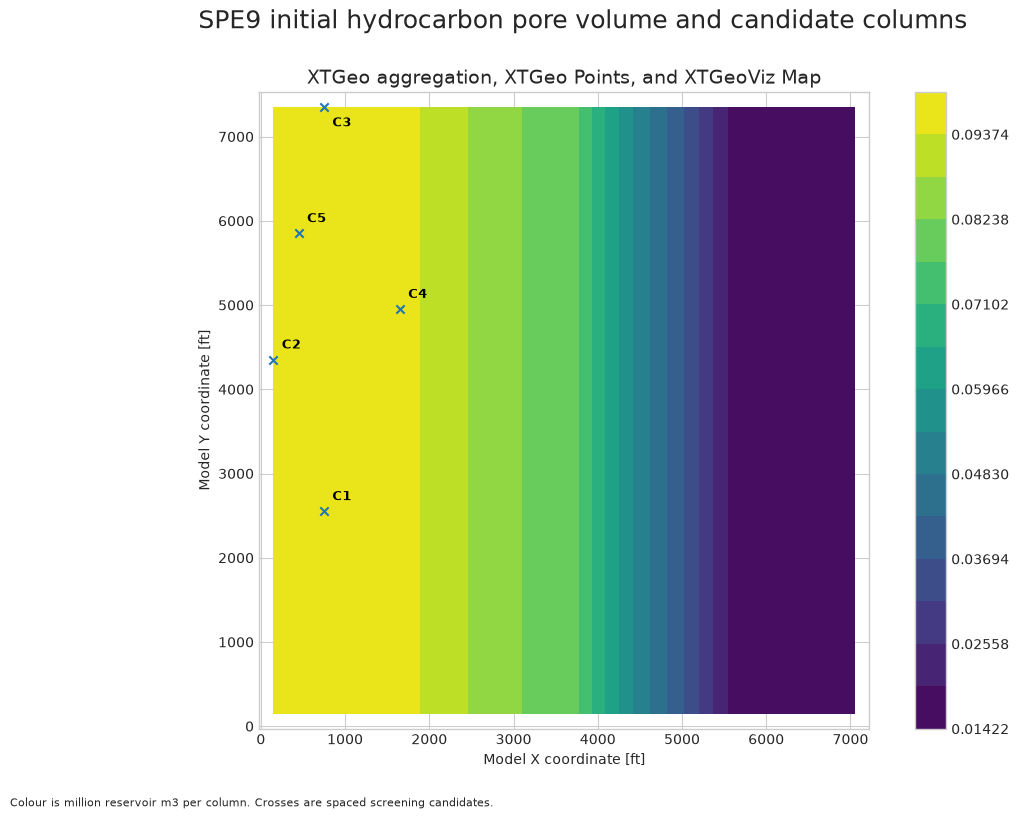

True

In [9]:
hcpv_surface = top_depth_surface.copy()
hcpv_surface.values = column_hcpv_m3 / 1.0e6

candidate_points = xtgeo.Points(
    values=[
        (
            row["model X [ft]"],
            row["model Y [ft]"],
            row["screening score"],
        )
        for _, row in candidate_table.iterrows()
    ],
    zname="SCREENING_SCORE",
)

candidate_map = Map()
candidate_map.contourlevels = 16
candidate_map.canvas(
    title="SPE9 initial hydrocarbon pore volume and candidate columns",
    subtitle="XTGeo aggregation, XTGeo Points, and XTGeoViz Map",
    infotext=(
        "Colour is million reservoir m3 per column. Crosses are spaced screening candidates."
    ),
)
candidate_map.plot_surface(
    hcpv_surface,
    colormap=plt.get_cmap("viridis"),
)
candidate_map.plot_points(candidate_points)
x_minimum, x_maximum = candidate_map._ax.get_xlim()
y_minimum, y_maximum = candidate_map._ax.get_ylim()
x_padding = 0.025 * (x_maximum - x_minimum)
y_padding = 0.025 * (y_maximum - y_minimum)
candidate_map._ax.set_xlim(x_minimum - x_padding, x_maximum + x_padding)
candidate_map._ax.set_ylim(y_minimum - y_padding, y_maximum + y_padding)
for _, row in candidate_table.iterrows():
    near_top_edge = row["model Y [ft]"] > y_maximum - 0.08 * (
        y_maximum - y_minimum
    )
    candidate_map._ax.annotate(
        f"C{int(row['rank'])}",
        (row["model X [ft]"], row["model Y [ft]"]),
        xytext=(6, -7 if near_top_edge else 6),
        textcoords="offset points",
        fontsize=9,
        color="black",
        weight="bold",
        verticalalignment="top" if near_top_edge else "bottom",
    )
candidate_map._ax.set_xlabel("Model X coordinate [ft]")
candidate_map._ax.set_ylabel("Model Y coordinate [ft]")
candidate_map.show()

## 8. Read the public black-oil PVT anchor

The `PVTO` table belongs to SPE9 and is separate from the illustrative compositional fluid used
later. Its saturated rows provide solution GOR $R_s$, bubble pressure $p_b$, oil formation-volume
factor $B_o$, and viscosity $\mu_o$. The deck uses psia, RB/STB, cP, and Mscf/STB.

The initial solution has approximately $R_s=1.39$ Mscf/STB and no free gas. The matching saturated
PVTO row therefore supplies $B_o=1.11$ RB/STB as the transparent initial oil-in-place anchor. A
full black-oil simulator would evaluate undersaturated compressibility cell by cell.

In [10]:
deck_text = deck_path.read_text(encoding="utf-8")
pvto_text = deck_text.split("PVTO", maxsplit=1)[1].split(
    "PVDG",
    maxsplit=1,
)[0]
number_pattern = re.compile(
    r"[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[Ee][-+]?\d+)?"
)

pvto_rows = []
for raw_line in pvto_text.splitlines():
    line = raw_line.strip()
    if not line or line.startswith("--"):
        continue
    numbers = [float(value) for value in number_pattern.findall(line)]
    if len(numbers) >= 4:
        rs_mscf_stb, pressure_psia, bo_rb_stb, viscosity_cp = numbers[:4]
        pvto_rows.append(
            {
                "Rs [Mscf/STB]": rs_mscf_stb,
                "bubble pressure [psia]": pressure_psia,
                "bubble pressure [bara]": pressure_psia * PSI_TO_BAR,
                "Bo [RB/STB]": bo_rb_stb,
                "oil viscosity [cP]": viscosity_cp,
            }
        )

pvto_table = pd.DataFrame(pvto_rows)
reference_row_index = (
    pvto_table["Rs [Mscf/STB]"] - weighted_solution_gor_mscf_stb
).abs().idxmin()
reference_pvto_row = pvto_table.loc[reference_row_index]
reference_bo_rb_stb = float(reference_pvto_row["Bo [RB/STB]"])
solution_gor_sm3_sm3 = (
    weighted_solution_gor_mscf_stb * MCSF_PER_STB_TO_SM3_PER_SM3
)

display(pvto_table.round(4))
print(
    "Selected initial anchor: "
    f"Rs={reference_pvto_row['Rs [Mscf/STB]']:.3f} Mscf/STB, "
    f"Pb={reference_pvto_row['bubble pressure [bara]']:.2f} bara, "
    f"Bo={reference_bo_rb_stb:.4f} RB/STB."
)
print(f"Converted solution GOR: {solution_gor_sm3_sm3:.2f} Sm3/Sm3.")

Selected initial anchor: Rs=1.390 Mscf/STB, Pb=248.21 bara, Bo=1.1100 RB/STB.
Converted solution GOR: 247.57 Sm3/Sm3.


,Rs [Mscf/STB],bubble pressure [psia],bubble pressure [bara],Bo [RB/STB],oil viscosity [cP]
0,0.000,14.7,1.0135,1.0000,1.20
1,0.165,400.0,27.5790,1.0120,1.17
2,0.335,800.0,55.1581,1.0255,1.14
3,0.500,1200.0,82.7371,1.0380,1.11
4,0.665,1600.0,110.3161,1.0510,1.08
5,0.828,2000.0,137.8951,1.0630,1.06
6,0.985,2400.0,165.4742,1.0750,1.03
7,1.130,2800.0,193.0532,1.0870,1.00
8,1.270,3200.0,220.6322,1.0985,0.98
9,1.390,3600.0,248.2113,1.1100,0.95


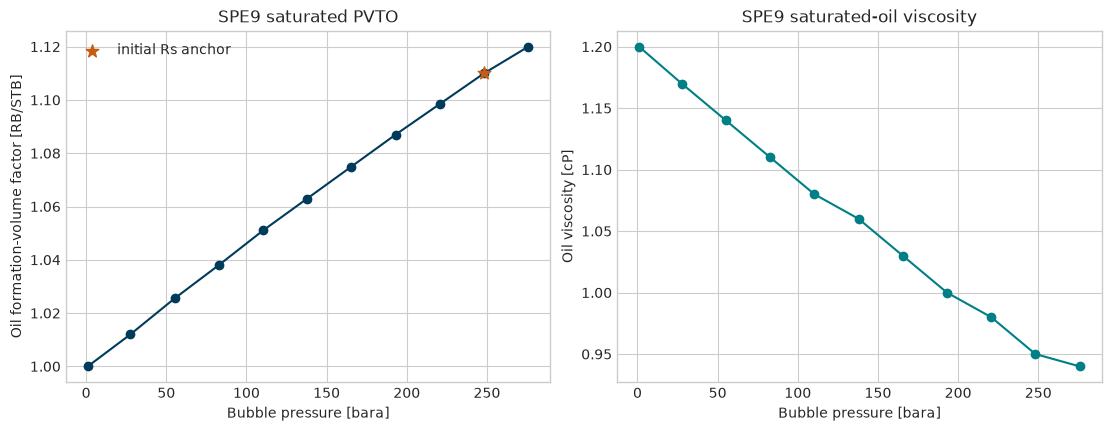

In [11]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.2),
    constrained_layout=True,
)
axes[0].plot(
    pvto_table["bubble pressure [bara]"],
    pvto_table["Bo [RB/STB]"],
    marker="o",
    color="#003B5C",
)
axes[0].scatter(
    [reference_pvto_row["bubble pressure [bara]"]],
    [reference_bo_rb_stb],
    s=90,
    marker="*",
    color="#C75B12",
    label="initial Rs anchor",
    zorder=3,
)
axes[0].set_xlabel("Bubble pressure [bara]")
axes[0].set_ylabel("Oil formation-volume factor [RB/STB]")
axes[0].set_title("SPE9 saturated PVTO")
axes[0].legend()

axes[1].plot(
    pvto_table["bubble pressure [bara]"],
    pvto_table["oil viscosity [cP]"],
    marker="o",
    color="#007F87",
)
axes[1].set_xlabel("Bubble pressure [bara]")
axes[1].set_ylabel("Oil viscosity [cP]")
axes[1].set_title("SPE9 saturated-oil viscosity")
plt.show()

## 9. Volumetric oil in place and stated uncertainty

The deterministic screening estimate is

$$N_{\mathrm{STOIIP}}=\frac{V_{HC,\mathrm{res}}}{B_o}$$

The uncertainty study is deliberately **not** inferred from the single SPE9 realization. It applies
transparent teaching distributions to pore-volume calibration, a global water-saturation shift,
$B_o$, and recovery factor. Each realization remains internally coherent:

$$N_{r}=\frac{m_{\phi,r}\sum V_{p}(1-S_w-\Delta S_{w,r})}{B_{o,r}},\qquad N_{\mathrm{rec},r}=R_{f,r}N_r$$

The 10th, 50th, and 90th percentiles are distribution summaries, not booked reserves classes.

In [12]:
deterministic_stoiip_sm3 = (
    hydrocarbon_pore_volume_total_m3 / reference_bo_rb_stb
)

rng = np.random.default_rng(RANDOM_SEED)
realization_count = 5_000
pore_volume_multiplier = np.clip(
    rng.normal(1.0, 0.05, realization_count),
    0.85,
    1.15,
)
water_saturation_shift = np.clip(
    rng.normal(0.0, 0.025, realization_count),
    -0.07,
    0.07,
)
bo_realizations = np.clip(
    rng.normal(reference_bo_rb_stb, 0.025, realization_count),
    1.04,
    1.18,
)
recovery_factor = np.clip(
    rng.triangular(0.20, 0.32, 0.45, realization_count),
    0.15,
    0.50,
)

pore_volume_rb_filled = np.ma.filled(values["PORV"], 0.0)
water_saturation_filled = np.ma.filled(values["SWAT"], 0.0)
base_hcpv_rb = float(
    np.sum(pore_volume_rb_filled * (1.0 - water_saturation_filled))
)
total_pore_volume_rb = float(np.sum(pore_volume_rb_filled))
hcpv_realizations_rb = pore_volume_multiplier * (
    base_hcpv_rb - water_saturation_shift * total_pore_volume_rb
)
stoiip_realizations_sm3 = (
    hcpv_realizations_rb
    * RESERVOIR_BARREL_TO_M3
    / bo_realizations
)
recoverable_oil_realizations_sm3 = (
    stoiip_realizations_sm3 * recovery_factor
)

quantile_labels = ["low (10th percentile)", "base (50th percentile)", "high (90th percentile)"]
quantile_probabilities = [0.10, 0.50, 0.90]
resource_table = pd.DataFrame(
    {
        "case": quantile_labels,
        "STOIIP [million Sm3]": np.quantile(
            stoiip_realizations_sm3,
            quantile_probabilities,
        )
        / 1.0e6,
        "recoverable oil [million Sm3]": np.quantile(
            recoverable_oil_realizations_sm3,
            quantile_probabilities,
        )
        / 1.0e6,
    }
)

print(
    "Deterministic SPE9 screening STOIIP: "
    f"{deterministic_stoiip_sm3 / 1.0e6:.3f} million Sm3."
)
display(resource_table.round(3))

Deterministic SPE9 screening STOIIP: 34.043 million Sm3.


,case,STOIIP [million Sm3],recoverable oil [million Sm3]
0,low (10th percentile),31.005,8.569
1,base (50th percentile),34.031,11.004
2,high (90th percentile),37.255,13.623


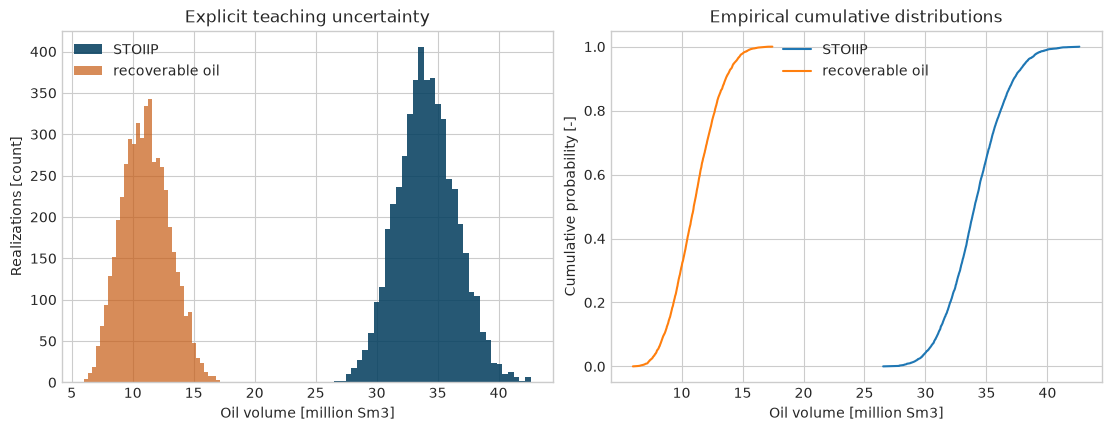

In [13]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.2),
    constrained_layout=True,
)
axes[0].hist(
    stoiip_realizations_sm3 / 1.0e6,
    bins=35,
    color="#003B5C",
    alpha=0.85,
    label="STOIIP",
)
axes[0].hist(
    recoverable_oil_realizations_sm3 / 1.0e6,
    bins=35,
    color="#C75B12",
    alpha=0.70,
    label="recoverable oil",
)
axes[0].set_xlabel("Oil volume [million Sm3]")
axes[0].set_ylabel("Realizations [count]")
axes[0].set_title("Explicit teaching uncertainty")
axes[0].legend()

sorted_stoiip = np.sort(stoiip_realizations_sm3 / 1.0e6)
sorted_recoverable = np.sort(recoverable_oil_realizations_sm3 / 1.0e6)
cumulative_probability = (
    np.arange(1, realization_count + 1) / realization_count
)
axes[1].plot(sorted_stoiip, cumulative_probability, label="STOIIP")
axes[1].plot(
    sorted_recoverable,
    cumulative_probability,
    label="recoverable oil",
)
axes[1].set_xlabel("Oil volume [million Sm3]")
axes[1].set_ylabel("Cumulative probability [-]")
axes[1].set_title("Empirical cumulative distributions")
axes[1].legend()
axes[0].set_xticks(np.arange(5.0, 41.0, 5.0))
axes[1].set_xticks(np.arange(10.0, 41.0, 5.0))
plt.show()

## 10. Compositional bridge for NeqSim

SPE9 supplies black-oil tables, not a component assay. A process simulator nevertheless needs a
component-resolved feed. The SRK assay below is therefore an **illustrative, open teaching fluid**
and is not asserted to reproduce SPE9 PVT. It contains measured-component names, C7-C19 TBP cuts,
a characterized C20+ fraction, classic mixing, and Péneloux volume correction.

The workflow uses the SPE9 solution GOR and rate scenarios to recombine stock-oil and stock-gas
templates from this assay. Project work must replace it with laboratory PVT evidence and a tuned,
approved fluid model.

In [14]:
RESERVOIR_TEMPERATURE_C = 97.5
RESERVOIR_TEMPERATURE_K = RESERVOIR_TEMPERATURE_C + 273.15
INITIAL_RESERVOIR_PRESSURE_BARA = weighted_initial_pressure_bara

LIGHT_COMPONENTS = [
    ("nitrogen", 0.39),
    ("CO2", 0.30),
    ("methane", 40.20),
    ("ethane", 7.61),
    ("propane", 7.95),
    ("i-butane", 1.19),
    ("n-butane", 4.08),
    ("i-pentane", 1.39),
    ("n-pentane", 2.15),
    ("n-hexane", 2.79),
]
TBP_CUTS = [
    ("C7", 4.28, 0.095, 0.729),
    ("C8", 4.31, 0.106, 0.749),
    ("C9", 3.08, 0.121, 0.770),
    ("C10", 2.47, 0.135, 0.786),
    ("C11", 1.91, 0.148, 0.792),
    ("C12", 1.69, 0.161, 0.804),
    ("C13", 1.59, 0.175, 0.819),
    ("C14", 1.22, 0.196, 0.833),
    ("C15", 1.25, 0.206, 0.836),
    ("C16", 1.00, 0.225, 0.843),
    ("C17", 0.99, 0.236, 0.840),
    ("C18", 0.92, 0.245, 0.846),
    ("C19", 0.60, 0.265, 0.857),
]
PLUS_FRACTION = ("C20", 6.64, 0.453, 0.918)


def build_teaching_reservoir_fluid():
    fluid_model = jneqsim.thermo.system.SystemSrkEos(
        RESERVOIR_TEMPERATURE_K,
        INITIAL_RESERVOIR_PRESSURE_BARA,
    )
    for component_name, amount_mol_percent in LIGHT_COMPONENTS:
        fluid_model.addComponent(component_name, amount_mol_percent)
    for cut_name, amount, molar_mass, relative_density in TBP_CUTS:
        fluid_model.addTBPfraction(
            cut_name,
            amount,
            molar_mass,
            relative_density,
        )
    plus_name, plus_amount, plus_molar_mass, plus_density = PLUS_FRACTION
    fluid_model.addPlusFraction(
        plus_name,
        plus_amount,
        plus_molar_mass,
        plus_density,
    )
    characterization = fluid_model.getCharacterization()
    characterization.getLumpingModel().setNumberOfPseudoComponents(12)
    characterization.characterisePlusFraction()
    fluid_model.setMixingRule("classic")
    fluid_model.useVolumeCorrection(True)
    fluid_model.init(0)
    fluid_model.init(1)
    return fluid_model


reservoir_fluid = build_teaching_reservoir_fluid()
assay_sum_mol_percent = (
    sum(amount for _, amount in LIGHT_COMPONENTS)
    + sum(row[1] for row in TBP_CUTS)
    + PLUS_FRACTION[1]
)

saturation_pressure_calculation = (
    jneqsim.pvtsimulation.simulation.SaturationPressure(
        reservoir_fluid.clone()
    )
)
saturation_pressure_calculation.setTemperature(
    RESERVOIR_TEMPERATURE_C,
    "C",
)
saturation_pressure_calculation.run()
teaching_fluid_bubble_pressure_bara = float(
    saturation_pressure_calculation.getSaturationPressure()
)

stock_tank_state = reservoir_fluid.clone()
stock_tank_state.setTemperature(STANDARD_TEMPERATURE_C, "C")
stock_tank_state.setPressure(STANDARD_PRESSURE_BARA, "bara")
TPflash(stock_tank_state)
stock_tank_state.initPhysicalProperties()
stock_oil_template = stock_tank_state.phaseToSystem("oil")
stock_gas_template = stock_tank_state.phaseToSystem("gas")

fluid_audit = pd.DataFrame(
    {
        "quantity": [
            "input assay closure",
            "characterized components",
            "EOS",
            "mixing rule",
            "teaching-fluid bubble pressure",
            "SPE9 weighted initial pressure",
        ],
        "value": [
            assay_sum_mol_percent,
            reservoir_fluid.getNumberOfComponents(),
            "SRK",
            "classic",
            teaching_fluid_bubble_pressure_bara,
            INITIAL_RESERVOIR_PRESSURE_BARA,
        ],
        "unit": ["mol%", "count", "-", "-", "bara", "bara"],
    }
)
display(fluid_audit)

,quantity,value,unit
0,input assay closure,100.0,mol%
1,characterized components,22,count
2,EOS,SRK,-
3,mixing rule,classic,-
4,teaching-fluid bubble pressure,193.240934,bara
5,SPE9 weighted initial pressure,268.971411,bara


## 11. Three rate cases and a composable topside process

Oil rates and water cuts are explicit teaching scenarios. Gas rate follows the SPE9 initial solution
GOR. Standard gas and stock-tank oil use 15 °C and 1.01325 bara; water rate is actual liquid m³/d.

Each case executes this NeqSim chain:

`stock oil + stock gas + water → 70 bara/65 °C arrival → choke → cooler → HP three-phase separator → oil letdown/LP separator + HP/LP gas compression to 140 bara`

The process gate is the total mass residual

$$\varepsilon_m=\dot m_{feed}-\dot m_{gas}-\dot m_{oil}-\dot m_{water}$$

In [15]:
scenario_table = pd.DataFrame(
    {
        "case": ["low", "base", "high"],
        "oil feed [Sm3/d]": [6_000.0, 10_000.0, 14_000.0],
        "water cut [-]": [0.10, 0.15, 0.20],
    }
)
scenario_table["gas feed [Sm3/d]"] = (
    scenario_table["oil feed [Sm3/d]"] * solution_gor_sm3_sm3
)
scenario_table["water feed [m3/d]"] = (
    scenario_table["oil feed [Sm3/d]"]
    * scenario_table["water cut [-]"]
    / (1.0 - scenario_table["water cut [-]"])
)
display(scenario_table.round(2))

,case,oil feed [Sm3/d],water cut [-],gas feed [Sm3/d],water feed [m3/d]
0,low,6000.0,0.10,1485410.90,666.67
1,base,10000.0,0.15,2475684.84,1764.71
2,high,14000.0,0.20,3465958.77,3500.00


In [16]:
water_probe = jneqsim.thermo.system.SystemSrkEos(
    STANDARD_TEMPERATURE_C + 273.15,
    STANDARD_PRESSURE_BARA,
)
water_probe.addComponent("water", 1.0)
water_molar_mass_kg_mol = float(
    water_probe.getComponent("water").getMolarMass()
)
stock_water_density_kg_m3 = 998.0


def reconstruct_wellhead_fluid(
    oil_rate_sm3_day,
    gas_rate_sm3_day,
    water_rate_m3_day,
):
    stock_oil = stock_oil_template.clone()
    stock_gas = stock_gas_template.clone()
    stock_oil.setTotalFlowRate(oil_rate_sm3_day, "m3/day")
    stock_gas.setTotalFlowRate(gas_rate_sm3_day, "Sm3/day")

    clearProcess()
    stock_oil_stream = stream("stock-oil component", stock_oil)
    stock_gas_stream = stream("stock-gas component", stock_gas)
    recombination_mixer = mixer("black-oil to compositional bridge")
    recombination_mixer.addStream(stock_oil_stream)
    recombination_mixer.addStream(stock_gas_stream)
    runProcess()

    reconstructed_fluid = (
        recombination_mixer.getOutletStream().getFluid().clone()
    )
    hydrocarbon_mass_flow_kg_s = reconstructed_fluid.getFlowRate(
        "kg/sec"
    )
    water_mass_flow_kg_s = (
        water_rate_m3_day
        * stock_water_density_kg_m3
        / SECONDS_PER_DAY
    )
    reconstructed_fluid.addComponent(
        "water",
        water_mass_flow_kg_s / water_molar_mass_kg_mol,
    )
    reconstructed_fluid.setMixingRule("classic")
    reconstructed_fluid.setMultiPhaseCheck(True)
    reconstructed_fluid.setTemperature(65.0, "C")
    reconstructed_fluid.setPressure(70.0, "bara")
    TPflash(reconstructed_fluid)
    reconstructed_fluid.initPhysicalProperties()

    expected_mass_flow_kg_s = (
        hydrocarbon_mass_flow_kg_s + water_mass_flow_kg_s
    )
    reconstruction_residual_kg_s = (
        reconstructed_fluid.getFlowRate("kg/sec")
        - expected_mass_flow_kg_s
    )
    return reconstructed_fluid, reconstruction_residual_kg_s


def run_topside_case(scenario):
    case_name = str(scenario["case"])
    feed_fluid, reconstruction_residual_kg_s = (
        reconstruct_wellhead_fluid(
            float(scenario["oil feed [Sm3/d]"]),
            float(scenario["gas feed [Sm3/d]"]),
            float(scenario["water feed [m3/d]"]),
        )
    )

    clearProcess()
    process_feed = stream(f"{case_name} arrival fluid", feed_fluid)
    inlet_choke = valve(
        f"{case_name} inlet choke",
        process_feed,
        p=55.0,
    )
    inlet_cooler = cooler(
        f"{case_name} inlet cooler",
        inlet_choke.getOutletStream(),
    )
    inlet_cooler.setOutTemperature(45.0 + 273.15)
    hp_separator = separator3phase(
        f"{case_name} HP three-phase separator",
        inlet_cooler.getOutletStream(),
    )

    oil_letdown = valve(
        f"{case_name} oil letdown",
        hp_separator.getOilOutStream(),
        p=2.0,
    )
    lp_separator = separator(
        f"{case_name} LP separator",
        oil_letdown.getOutletStream(),
    )
    hp_gas_compressor = compressor(
        f"{case_name} HP gas compressor",
        hp_separator.getGasOutStream(),
        pres=140.0,
    )
    lp_gas_compressor = compressor(
        f"{case_name} LP flash-gas compressor",
        lp_separator.getGasOutStream(),
        pres=140.0,
    )
    hp_gas_compressor.setIsentropicEfficiency(0.75)
    lp_gas_compressor.setIsentropicEfficiency(0.75)
    runProcess()

    gas_export_mass_kg_s = (
        hp_gas_compressor.getOutletStream().getFlowRate("kg/sec")
        + lp_gas_compressor.getOutletStream().getFlowRate("kg/sec")
    )
    oil_export_mass_kg_s = (
        lp_separator.getLiquidOutStream().getFlowRate("kg/sec")
    )
    produced_water_mass_kg_s = (
        hp_separator.getWaterOutStream().getFlowRate("kg/sec")
    )
    feed_mass_kg_s = process_feed.getFlowRate("kg/sec")
    process_mass_residual_kg_s = (
        feed_mass_kg_s
        - gas_export_mass_kg_s
        - oil_export_mass_kg_s
        - produced_water_mass_kg_s
    )
    compression_power_mw = (
        hp_gas_compressor.getPower() + lp_gas_compressor.getPower()
    ) / 1.0e6
    cooling_duty_mw_removed = abs(inlet_cooler.getDuty()) / 1.0e6

    return {
        "case": case_name,
        "oil feed [Sm3/d]": float(scenario["oil feed [Sm3/d]"]),
        "gas feed [Sm3/d]": float(scenario["gas feed [Sm3/d]"]),
        "water feed [m3/d]": float(scenario["water feed [m3/d]"]),
        "feed mass [kg/s]": feed_mass_kg_s,
        "export gas [kg/s]": gas_export_mass_kg_s,
        "export oil [kg/s]": oil_export_mass_kg_s,
        "produced water [kg/s]": produced_water_mass_kg_s,
        "compression [MW]": compression_power_mw,
        "cooling removed [MW]": cooling_duty_mw_removed,
        "mass residual [kg/s]": process_mass_residual_kg_s,
        "reconstruction residual [kg/s]": (
            reconstruction_residual_kg_s
        ),
    }

In [17]:
process_results = pd.DataFrame(
    [
        run_topside_case(scenario)
        for _, scenario in scenario_table.iterrows()
    ]
)
display(process_results.round(6))

facility_limits = {
    "oil feed [Sm3/d]": 15_000.0,
    "water feed [m3/d]": 4_000.0,
    "feed mass [kg/s]": 90.0,
    "compression [MW]": 6.0,
}
utilization_rows = []
for _, result in process_results.iterrows():
    for metric, limit in facility_limits.items():
        utilization_rows.append(
            {
                "case": result["case"],
                "constraint": metric,
                "load": result[metric],
                "limit": limit,
                "utilization [%]": result[metric] / limit * 100.0,
            }
        )

utilization_table = pd.DataFrame(utilization_rows)
bottleneck_table = (
    utilization_table.loc[
        utilization_table.groupby("case")["utilization [%]"].idxmax()
    ]
    .sort_values("case")
    .reset_index(drop=True)
)
display(bottleneck_table.round(2))

,case,oil feed [Sm3/d],gas feed [Sm3/d],water feed [m3/d],feed mass [kg/s],export gas [kg/s],export oil [kg/s],produced water [kg/s],compression [MW],cooling removed [MW],mass residual [kg/s],reconstruction residual [kg/s]
0,low,6000.0,1.485411e+06,666.666667,27.743592,17.028276,3.037093,7.678224,2.658859,1.868569,0.0,0.0
1,base,10000.0,2.475685e+06,1764.705882,53.788945,28.380371,5.061829,20.346745,4.431427,3.850091,0.0,-0.0
2,high,14000.0,3.465959e+06,3500.000000,87.195182,39.732380,7.086572,40.376230,6.203991,6.549027,0.0,-0.0


,case,constraint,load,limit,utilization [%]
0,base,compression [MW],4.43,6.0,73.86
1,high,compression [MW],6.20,6.0,103.40
2,low,compression [MW],2.66,6.0,44.31


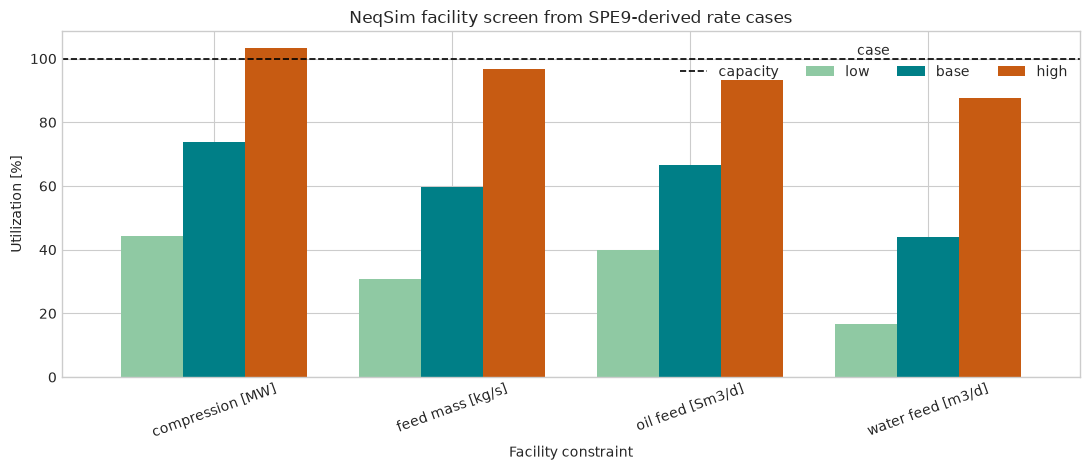

In [18]:
utilization_pivot = utilization_table.pivot(
    index="constraint",
    columns="case",
    values="utilization [%]",
)[["low", "base", "high"]]

axes = utilization_pivot.plot.bar(
    figsize=(11, 4.8),
    color=["#8FC9A3", "#007F87", "#C75B12"],
    width=0.78,
)
axes.axhline(
    100.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="capacity",
)
axes.set_ylabel("Utilization [%]")
axes.set_xlabel("Facility constraint")
axes.set_title("NeqSim facility screen from SPE9-derived rate cases")
axes.tick_params(axis="x", rotation=20)
axes.legend(title="case", ncol=4)
plt.tight_layout()
plt.show()

## 12. Reusable subsurface-to-facilities handoff

The final contract preserves the immutable source revision, unit system, XTGeo candidate locations,
volumetric summaries, NeqSim version, process boundary conditions, and bottlenecks. It can be passed
to a later OPM Flow, ERT, well, SURF, or host-capacity workflow without scraping figures.

The JSON file is useful for download, but its key contents are also displayed inline so it is not
the only evidence carrier.

In [19]:
handoff = {
    "schema": "neqsim-colab.xtgeo-subsurface-facilities.v1",
    "data": {
        "repository": "equinor/xtgeo-testdata",
        "commit": DATA_COMMIT,
        "case": "bench_spe9",
        "license": "LGPL-3.0",
        "unit_system": "ECLIPSE FIELD with explicit SI conversions",
    },
    "grid": {
        "dimensions": [grid.ncol, grid.nrow, grid.nlay],
        "active_cells": grid.nactive,
    },
    "volumetrics": {
        "pore_volume_m3": pore_volume_m3,
        "hydrocarbon_pore_volume_m3": hydrocarbon_pore_volume_total_m3,
        "deterministic_stoiip_sm3": deterministic_stoiip_sm3,
        "reference_bo_rb_stb": reference_bo_rb_stb,
    },
    "candidates": candidate_table.to_dict(orient="records"),
    "neqsim": {
        "version": version("neqsim"),
        "eos": "SRK",
        "mixing_rule": "classic",
        "fluid_basis": "illustrative teaching assay; not SPE9-matched PVT",
        "arrival_pressure_bara": 70.0,
        "arrival_temperature_c": 65.0,
        "export_pressure_bara": 140.0,
    },
    "facility_results": process_results.to_dict(orient="records"),
    "bottlenecks": bottleneck_table.to_dict(orient="records"),
}

handoff_path = DATA_DIRECTORY / "xtgeo_spe9_to_neqsim_handoff.json"
handoff_path.write_text(
    json.dumps(handoff, indent=2),
    encoding="utf-8",
)

handoff_summary = pd.DataFrame(
    {
        "item": [
            "data commit",
            "active cells",
            "HCPV",
            "deterministic STOIIP",
            "candidate columns",
            "process cases",
            "handoff path",
        ],
        "value": [
            DATA_COMMIT,
            grid.nactive,
            f"{hydrocarbon_pore_volume_total_m3 / 1.0e6:.3f} million rm3",
            f"{deterministic_stoiip_sm3 / 1.0e6:.3f} million Sm3",
            len(candidate_table),
            len(process_results),
            str(handoff_path),
        ],
    }
)
display(handoff_summary)
print(json.dumps(handoff["bottlenecks"], indent=2))

[
  {
    "case": "base",
    "constraint": "compression [MW]",
    "load": 4.431427407859532,
    "limit": 6.0,
    "utilization [%]": 73.85712346432554
  },
  {
    "case": "high",
    "constraint": "compression [MW]",
    "load": 6.203990796802694,
    "limit": 6.0,
    "utilization [%]": 103.39984661337824
  },
  {
    "case": "low",
    "constraint": "compression [MW]",
    "load": 2.6588593371372338,
    "limit": 6.0,
    "utilization [%]": 44.31432228562056
  }
]


,item,value
0,data commit,cad17f24e22c19c6cefe6f647185395cc0a11add
1,active cells,9000
2,HCPV,37.787 million rm3
3,deterministic STOIIP,34.043 million Sm3
4,candidate columns,5
5,process cases,3
6,handoff path,/tmp/neqsim_xtgeo_spe9/xtgeo_spe9_to_neqsim_ha...


## 13. Validation gates

The final cell checks source identity, geometry, physical bounds, the independent pore-volume
identity, candidate spacing, fluid construction, process conservation, monotonic load response,
and the reusable handoff. These checks are intentionally stricter than “the notebook ran”.

In [20]:
minimum_candidate_spacing = min(
    abs(first_i - second_i) + abs(first_j - second_j)
    for candidate_index, (first_i, first_j) in enumerate(selected_columns)
    for second_i, second_j in selected_columns[candidate_index + 1 :]
)

validation_checks = {
    "four source files are checksum verified": bool(
        download_table["verified"].all()
    ),
    "grid dimensions are 24 x 25 x 15": (
        (grid.ncol, grid.nrow, grid.nlay) == (24, 25, 15)
    ),
    "all 9000 cells are active": grid.nactive == 9_000,
    "porosity stays inside (0, 1)": bool(
        np.ma.min(values["PORO"]) > 0.0
        and np.ma.max(values["PORO"]) < 1.0
    ),
    "permeability is positive": bool(np.ma.min(values["PERMX"]) > 0.0),
    "water saturation stays inside [0, 1]": bool(
        np.ma.min(values["SWAT"]) >= 0.0
        and np.ma.max(values["SWAT"]) <= 1.0
    ),
    "initial gas saturation is zero": bool(
        np.ma.max(np.ma.abs(values["SGAS"])) == 0.0
    ),
    "initial pressure is positive": bool(
        np.ma.min(values["PRESSURE"]) > 0.0
    ),
    "pore-volume identity closes below 1e-6": (
        maximum_pore_volume_relative_residual < 1.0e-6
    ),
    "HCPV is positive and below total pore volume": (
        0.0 < hydrocarbon_pore_volume_total_m3 < pore_volume_m3
    ),
    "five candidate columns are selected": len(candidate_table) == 5,
    "candidate spacing is at least five grid steps": (
        minimum_candidate_spacing >= 5
    ),
    "teaching assay closes to 100 mol%": math.isclose(
        assay_sum_mol_percent,
        100.0,
        rel_tol=0.0,
        abs_tol=1.0e-12,
    ),
    "teaching fluid bubble pressure is below initial pressure": (
        0.0
        < teaching_fluid_bubble_pressure_bara
        < INITIAL_RESERVOIR_PRESSURE_BARA
    ),
    "all process mass residuals are below 1e-8 kg/s": bool(
        process_results["mass residual [kg/s]"].abs().max() < 1.0e-8
    ),
    "all reconstruction residuals are below 1e-8 kg/s": bool(
        process_results["reconstruction residual [kg/s]"].abs().max()
        < 1.0e-8
    ),
    "compression rises monotonically with rate": bool(
        process_results["compression [MW]"].is_monotonic_increasing
    ),
    "JSON handoff exists and is nonempty": (
        handoff_path.is_file() and handoff_path.stat().st_size > 0
    ),
}

validation_table = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)
display(validation_table)
if not all(validation_checks.values()):
    failed_checks = [
        check for check, passed in validation_checks.items() if not passed
    ]
    raise AssertionError(f"Validation failed: {failed_checks}")
print(f"Validation passed: {sum(validation_checks.values())}/{len(validation_checks)} checks.")

Validation passed: 18/18 checks.


,check,passed
0,four source files are checksum verified,True
1,grid dimensions are 24 x 25 x 15,True
2,all 9000 cells are active,True
3,"porosity stays inside (0, 1)",True
4,permeability is positive,True
5,"water saturation stays inside [0, 1]",True
6,initial gas saturation is zero,True
7,initial pressure is positive,True
8,pore-volume identity closes below 1e-6,True
9,HCPV is positive and below total pore volume,True


## 14. Interpretation, limitations, and exercises

### What the workflow establishes

- The public SPE9 files form a self-consistent $24\times25\times15$ grid with 9000 active cells.
- The field-unit pore-volume identity closes independently before any volumetric result is used.
- XTGeo objects remain composable: `Grid`, `GridProperty`, `RegularSurface`, and `Points` are reused
  rather than converted into untraceable arrays at the input boundary.
- XTGeoViz renders the actual XTGeo surface objects and candidate points as stored static outputs.
- NeqSim conserves the reconstructed gas-oil-water feed through separation and compression while
  exposing equipment loads and the limiting constraint for each scenario.

### Limitations

- SPE9 is a synthetic benchmark. It has no seismic interpretation, real wells, faults requiring
  development decisions, geomechanical constraints, or approved reserves basis.
- The candidate score is a deterministic screening proxy. It omits drainage overlap, anisotropy,
  pressure interference, well cost, completion limits, and dynamic displacement.
- The uncertainty distributions are stated teaching assumptions, not an ensemble calibrated to
  data. Percentiles are not reserves categories.
- The SPE9 PVTO table and the NeqSim SRK assay are intentionally separate. The assay has not been
  regressed to SPE9 or laboratory data.
- Equilibrium separators omit residence time, entrainment, foaming, control, relief, mechanical
  design, compressor maps, and availability. Capacity limits are illustrative.
- Project use requires a qualified PVT model, dynamic reservoir simulation (for example OPM Flow),
  well/SURF models, measured equipment envelopes, economics, and independent assurance.

### Suggested exercises

1. Load a restart property from `BENCH_SPE9.UNRST` and animate pressure or saturation with XTGeo.
2. Replace the greedy proxy with a spacing-constrained multi-objective well-placement optimizer.
3. Export candidate `Points` to CSV, RMS points, or an OPM `WELSPECS`/`COMPDAT` proposal.
4. Run SPE9 in OPM Flow and preserve realization and well identities in the facility handoff.
5. Regress the NeqSim assay to a public compositional PVT dataset before recombination.
6. Add native compressor maps, separator mechanical design, and shared-driver constraints.

### References and licences

- [XTGeo source and documentation](https://github.com/equinor/xtgeo) — LGPL-3.0.
- [XTGeoViz source](https://github.com/equinor/xtgeoviz) and
  [documentation](https://equinor.github.io/xtgeoviz/) — LGPL-3.0.
- [XTGeo public test data](https://github.com/equinor/xtgeo-testdata) — LGPL-3.0;
  exact data commit recorded above.
- Killough, J. E. (1995), *Ninth SPE Comparative Solution Project: A Reexamination of Black-Oil
  Simulation*, [SPE-29110-MS](https://doi.org/10.2118/29110-MS).
- [NeqSim](https://github.com/equinor/neqsim) and
  [NeqSim documentation](https://equinor.github.io/neqsimhome/) — Apache-2.0.

No new NeqSim defect or missing public API was found while building this notebook.